In [3]:
from pathlib import Path
from typing import cast

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
RUNS_DIR = Path.cwd().parent / "runs"

data = pd.read_csv(RUNS_DIR / "__old" / "sweep-dncnn-256x256" / "baseline.csv")
baseline_labels = np.array([int(x.split("x")[0]) for x in data["dataset"] if x != "all-avg"])
baseline_losses = data.loc[data["dataset"] != "all-avg"]["value"].to_numpy()

run_paths = [
    RUNS_DIR / "__old" / "sweep-classic-64x64",
    RUNS_DIR / "__old" / "sweep-classic-128x128",
    RUNS_DIR / "__old" / "sweep-classic-256x256",
    RUNS_DIR / "__old" / "sweep-classic-mixed",
    RUNS_DIR / "__old" / "sweep-dncnn-64x64",
    RUNS_DIR / "__old" / "sweep-dncnn-128x128",
    RUNS_DIR / "__old" / "sweep-dncnn-256x256",
    RUNS_DIR / "__old" / "sweep-dncnn-mixed",
    RUNS_DIR / "__old" / "sweep-interp-64x64",
    RUNS_DIR / "__old" / "sweep-interp-128x128",
    RUNS_DIR / "__old" / "sweep-interp-256x256",
    RUNS_DIR / "__old" / "sweep-interp-mixed",
    RUNS_DIR / "__old2" / "heat-64x64",
    RUNS_DIR / "__old2" / "heat-128x128",
    RUNS_DIR / "__old2" / "heat-256x256",
    RUNS_DIR / "__old2" / "heat-mixed",
    RUNS_DIR / "SmallResUNet64",
    RUNS_DIR / "SmallResUNet128",
    RUNS_DIR / "SmallResUNet256",
    RUNS_DIR / "SmallResUNetMixed",
    RUNS_DIR / "SpatResU64",
    RUNS_DIR / "SpatResU128",
    RUNS_DIR / "SpatResU256",
    RUNS_DIR / "SpecResi64",
    RUNS_DIR / "SpecResi128",
    RUNS_DIR / "SpecResi256",
    RUNS_DIR / "SpecResiMixed",
    RUNS_DIR / "SpecResU64",
    RUNS_DIR / "SpecResU128",
    RUNS_DIR / "SpecResU256",
    RUNS_DIR / "SpecResUMixed",
    RUNS_DIR / "sweep-fewconv-unet-64x64",
    RUNS_DIR / "sweep-fewconv-unet-128x128",
    RUNS_DIR / "sweep-fewconv-unet-256x256",
    RUNS_DIR / "sweep-fewconv-unet-mixed",
    RUNS_DIR / "sweep-unet-64x64-pool",
    RUNS_DIR / "sweep-unet-128x128-pool",
    RUNS_DIR / "sweep-unet-256x256-pool",
    RUNS_DIR / "sweep-unet-mixed-pool",
]

FileNotFoundError: [Errno 2] No such file or directory: '/home/aa609734/Projects/FNO-UNet/runs/__old/sweep-classic-64x64/test-results.csv'

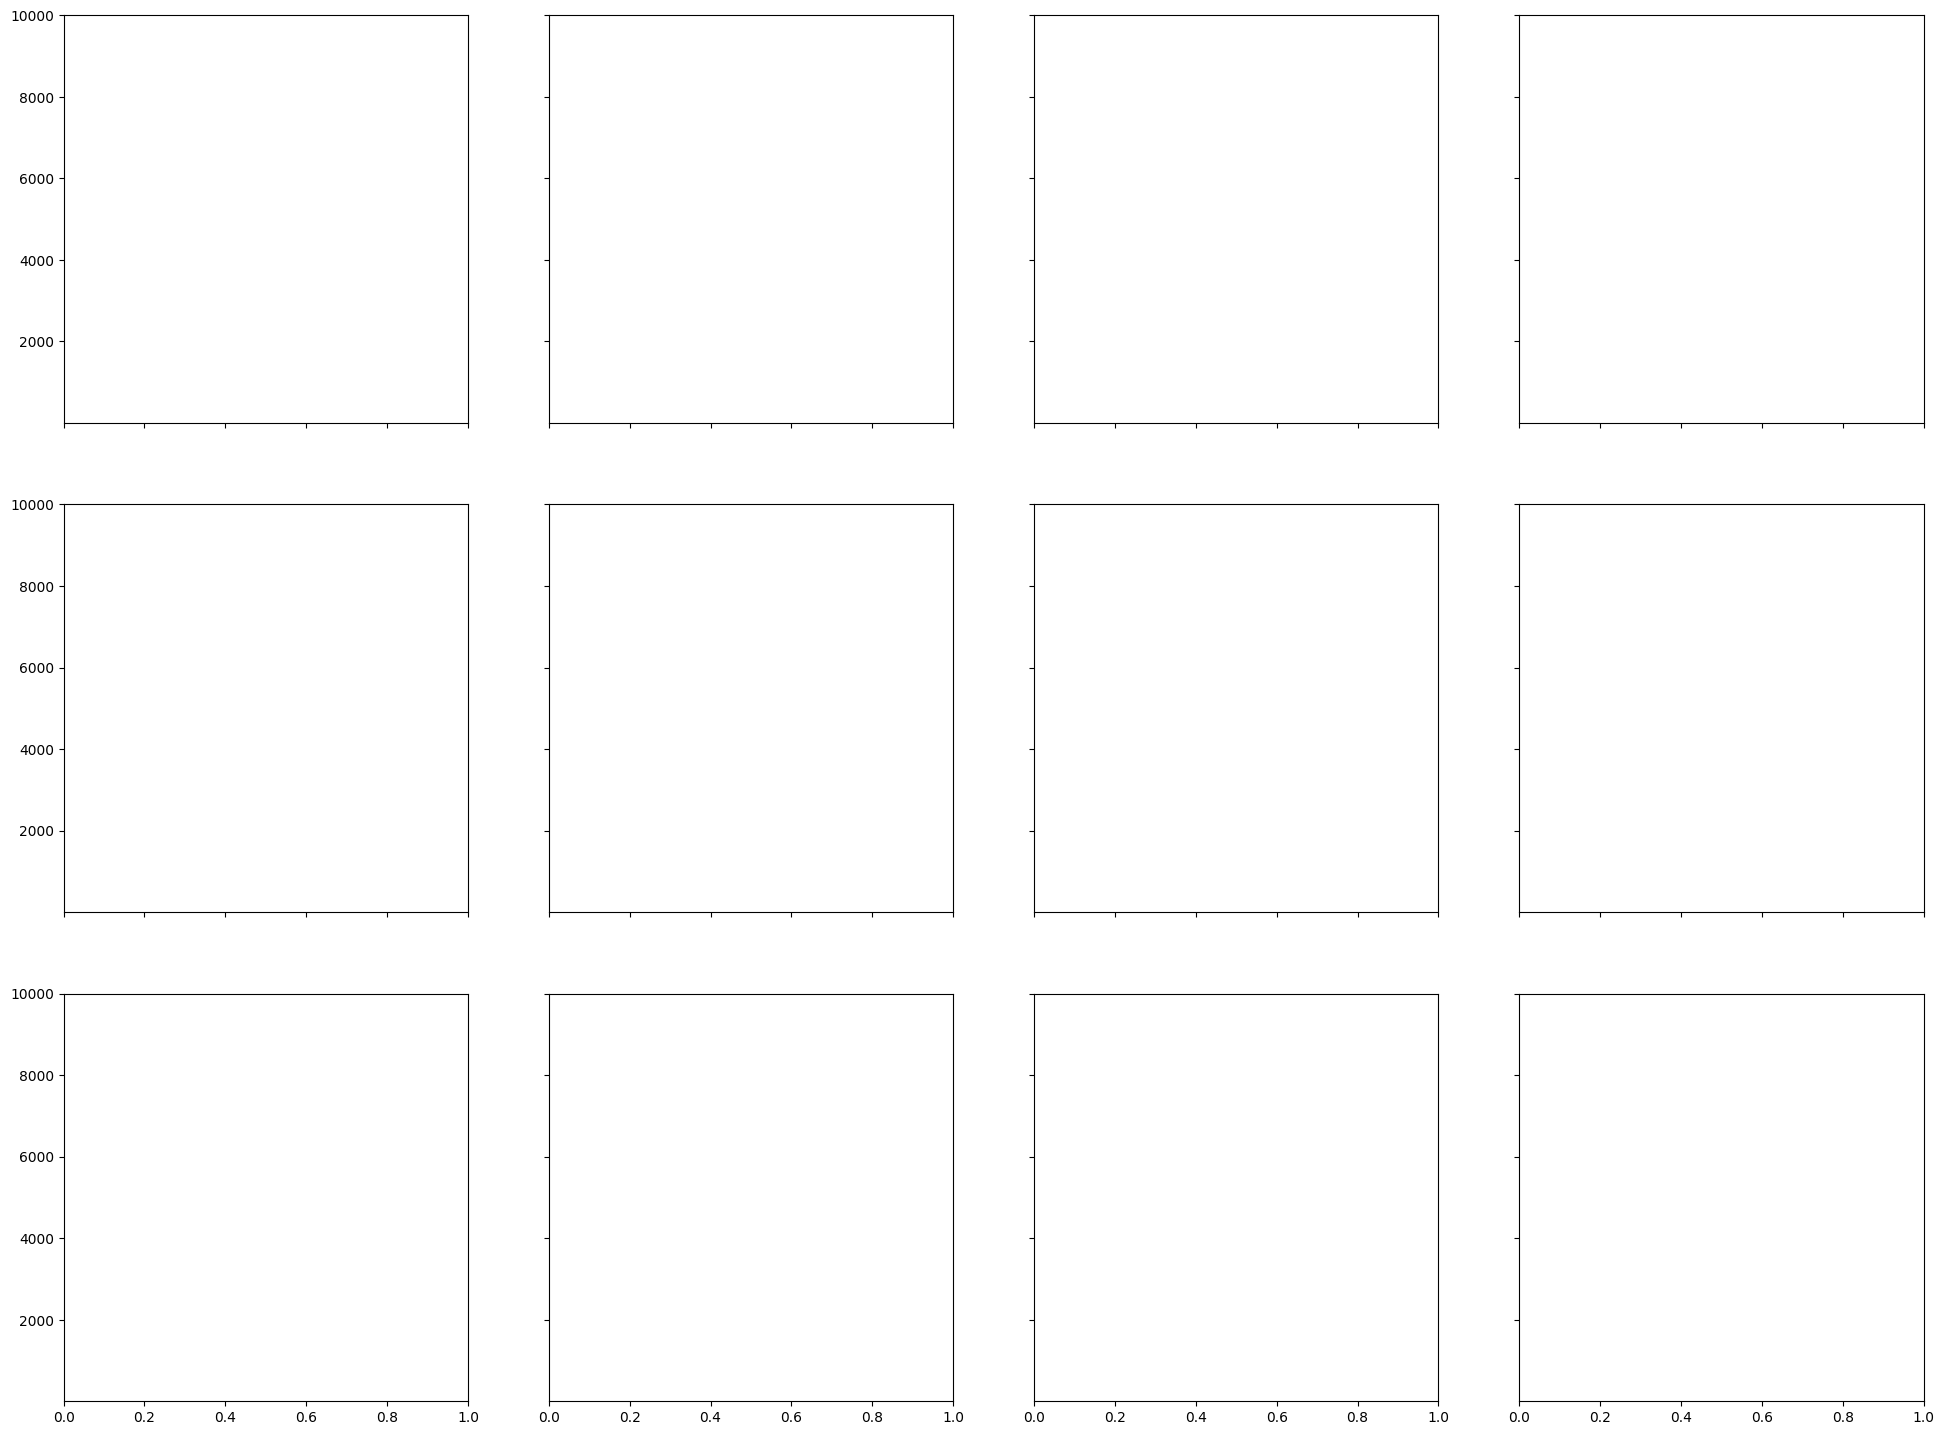

In [5]:
plt.subplots(3, 4, figsize=(24, 18), sharex=True, sharey=True)
plt.ylim(1e0, 1e4)
for i, part in enumerate(["classic", "dncnn", "interp", "heat", "SmallResUNet", "SpatRes", "SpecResi", "SpecResU", "fewconv", "pool"]):
    plt.subplot(3, 4, i + 1)
    for run_path in run_paths:
        if part not in run_path.name:
            continue
        data = pd.read_csv(run_path / "test-results.csv")
        sizes = np.array([int(x.split("x")[0]) for x in data["dataset"] if x != "all-avg"])
        data.rename(columns={" value": "value"}, inplace=True)
        losses = data.loc[data["dataset"] != "all-avg"]["value"].to_numpy()
        plt.plot(sizes, losses, label=run_path.name)
        best_i = np.argmin(losses)
        plt.scatter(sizes[best_i], losses[best_i])
        print(f"{run_path.name+':':25} {sizes[best_i]: >3d}x{sizes[best_i]}")
    plt.plot(baseline_labels, baseline_losses, "--", label="baseline")
    plt.yscale("log")
    plt.legend(fontsize=8, loc="upper right")
    plt.scatter([i for i in range(300)], [float("NaN") for _ in range(300)])
    plt.grid()
plt.subplot(3, 4, 11)
plt.axis("off")
plt.subplot(3, 4, 12)
plt.axis("off")
plt.show()

In [6]:
RUNS_DIR = Path.cwd().parent / "runs"

data = pd.read_csv(RUNS_DIR / "FNO-64x64" / "baseline.csv")
baseline_labels = np.array([int(x.split("x")[0]) for x in data["dataset"] if x != "all-avg"])
baseline_losses = data.loc[data["dataset"] != "all-avg"]["value"].to_numpy()

data = {}
for run in ["FNO-64x64","FNO-128x128","FNO-256x256","FNO-mixed","UFNO-64x64","UFNO-128x128","UFNO-256x256","UFNO-mixed","UNet-64x64","UNet-128x128","UNet-256x256","UNet-mixed"]:
    tmp = None
    for i in range(2):
        raw_data = pd.read_csv(RUNS_DIR / f"{run}-{i+1}" / "test-results.csv")
        raw_data.rename(columns={" value": "value"}, inplace=True)
        raw_data.rename(columns={" metric": "metric"}, inplace=True)
        labels = np.array([int(x.split("x")[0]) for x in raw_data["dataset"] if x != "all-avg"])
        losses = raw_data.loc[(raw_data["dataset"] != "all-avg") & (raw_data["metric"] == " loss")]["value"]
        if tmp is None:
            tmp = {labels[i]: losses[i] for i in range(len(labels))}
        else:
            for i in range(len(labels)):
                tmp[labels[i]] += losses[i]
    data[run] = {k: v / 2 for k, v in cast(dict[str, float], tmp).items()}

FileNotFoundError: [Errno 2] No such file or directory: '/home/aa609734/Projects/FNO-UNet/runs/FNO-64x64/baseline.csv'

KeyError: '__old/sweep-classic-64x64'

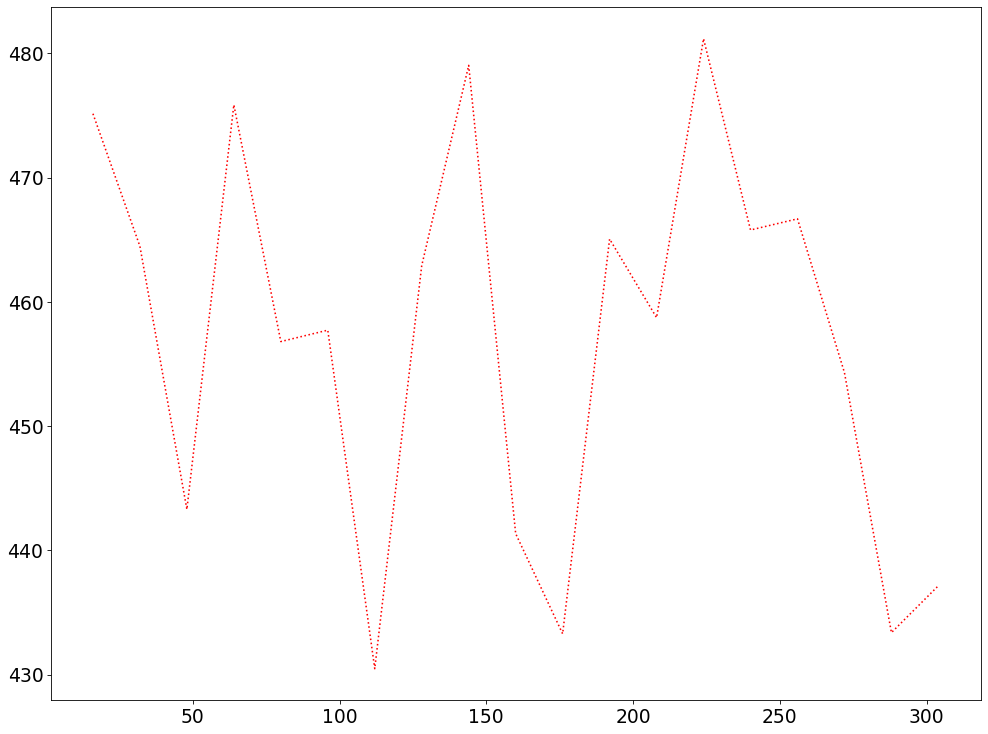

In [7]:
matplotlib.rc("font", **{"family": "sans-serif", "weight": "normal", "size": 18})
plt.figure(figsize=(16, 12), dpi=75)
plt.plot(baseline_labels, baseline_losses, "r:", label="baseline")
# for i, run in enumerate(["FNO-64x64","FNO-128x128","FNO-256x256","FNO-mixed","UFNO-64x64","UFNO-128x128","UFNO-256x256","UFNO-mixed","UNet-64x64","UNet-128x128","UNet-256x256","UNet-mixed"]):
for i, run in enumerate(["__old/sweep-classic-64x64"]):
    plt.plot(data[run].keys(), data[run].values(), color=f"C{i%4}", label="BABA", linestyle=["-","--","-.-"][i%4])
    best_size = min(data[run].items(), key=lambda x: x[1])[0]
    plt.scatter(best_size, data[run][best_size], color=f"C{i%4}")
    print(f"{run+':':25} {best_size: >3d}x{best_size}")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Resolution")
plt.ylabel("MSE")
plt.yscale("log")
plt.ylim(1e0, 1e4)
plt.tight_layout()
plt.grid()
plt.show()